In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
from ydata_profiling import ProfileReport
from reportlab.pdfgen import canvas
from matplotlib.backends.backend_pdf import PdfPages


In [6]:
# For reproducibility
np.random.seed(42)

n_rows = 200_000

# Make them float so they can hold NaN
customer_ids = np.random.randint(1, 20_001, size=n_rows).astype(float)
account_ids = np.random.randint(1, 50_001, size=n_rows).astype(float)

# Random transaction dates over 2 years
date_range = pd.date_range("2024-01-01", "2025-12-31", freq="D")
txn_dates = np.random.choice(date_range, size=n_rows)

txn_types = np.random.choice(
    ["DEPOSIT", "WITHDRAWAL", "TRANSFER_OUT", "TRANSFER_IN", "CARD_PAYMENT"],
    size=n_rows,
    p=[0.25, 0.25, 0.15, 0.15, 0.20]
)

channels = np.random.choice(
    ["BRANCH", "ATM", "MOBILE_APP", "WEB", "POS"],
    size=n_rows,
    p=[0.15, 0.25, 0.25, 0.15, 0.20]
)

regions = np.random.choice(
    ["North", "South", "East", "West", "Central"],
    size=n_rows
)

# Base amounts, different distributions by transaction type
base_amounts = np.random.lognormal(mean=3, sigma=0.8, size=n_rows) * 10

# Make withdrawals/transfer_out negative
amounts = base_amounts.copy()
amounts[np.isin(txn_types, ["WITHDRAWAL", "TRANSFER_OUT", "CARD_PAYMENT"])] *= -1

# Random product types per transaction
products = np.random.choice(
    ["Current", "Savings", "CreditCard", "Mortgage", "Loan"],
    size=n_rows,
    p=[0.45, 0.25, 0.15, 0.05, 0.10]
)

# Add some intentional missing values and noise
customer_ids[np.random.choice(n_rows, size=500, replace=False)] = np.nan
channels[np.random.choice(n_rows, size=400, replace=False)] = None
amounts[np.random.choice(n_rows, size=300, replace=False)] = np.nan

bank_df = pd.DataFrame({
    "transaction_id": np.arange(1, n_rows + 1),
    "customer_id": customer_ids,
    "account_id": account_ids,
    "transaction_date": txn_dates,
    "transaction_type": txn_types,
    "channel": channels,
    "region": regions,
    "product_type": products,
    "amount": amounts
})

bank_df.head().T


,0,1,2,3,4
transaction_id,1,2,3,4,5
customer_id,15796.0,861.0,5391.0,11965.0,11285.0
account_id,5665.0,23542.0,10969.0,18082.0,49885.0
transaction_date,2025-09-25 00:00:00,2025-06-29 00:00:00,2025-08-11 00:00:00,2024-08-22 00:00:00,2024-04-14 00:00:00
transaction_type,DEPOSIT,TRANSFER_IN,DEPOSIT,WITHDRAWAL,DEPOSIT
channel,POS,MOBILE_APP,MOBILE_APP,BRANCH,BRANCH
region,West,East,North,South,East
product_type,Current,Loan,Current,Savings,Savings
amount,315.259852,346.504217,623.284591,-207.917167,114.654366


In [7]:
bank_df.shape

(200000, 9)

## Understand the data (EDA)

In [8]:
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    200000 non-null  int64         
 1   customer_id       199500 non-null  float64       
 2   account_id        200000 non-null  float64       
 3   transaction_date  200000 non-null  datetime64[ns]
 4   transaction_type  200000 non-null  object        
 5   channel           200000 non-null  object        
 6   region            200000 non-null  object        
 7   product_type      200000 non-null  object        
 8   amount            199700 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 13.7+ MB


In [9]:
# first rows
bank_df.head()

,transaction_id,customer_id,account_id,transaction_date,transaction_type,channel,region,product_type,amount
0,1,15796.0,5665.0,2025-09-25,DEPOSIT,POS,West,Current,315.259852
1,2,861.0,23542.0,2025-06-29,TRANSFER_IN,MOBILE_APP,East,Loan,346.504217
2,3,5391.0,10969.0,2025-08-11,DEPOSIT,MOBILE_APP,North,Current,623.284591
3,4,11965.0,18082.0,2024-08-22,WITHDRAWAL,BRANCH,South,Savings,-207.917167
4,5,11285.0,49885.0,2024-04-14,DEPOSIT,BRANCH,East,Savings,114.654366


In [11]:
# Numeric summary
bank_df.describe(include="number")

,transaction_id,customer_id,account_id,amount
count,200000.000000,199500.000000,200000.000000,199700.000000
mean,100000.500000,10018.486952,25037.702230,-55.924507
std,57735.171256,5771.702363,14445.606968,374.583537
min,1.000000,1.000000,1.000000,-5894.037649
25%,50000.750000,5022.000000,12523.000000,-237.461664
50%,100000.500000,10021.000000,25066.000000,-93.343289
75%,150000.250000,15012.000000,37561.000000,154.971017
max,200000.000000,20000.000000,50000.000000,6147.860465


In [12]:
# Categorical summary
bank_df.describe(include= "object")

,transaction_type,channel,region,product_type
count,200000,200000,200000,200000
unique,5,6,5,5
top,WITHDRAWAL,ATM,East,Current
freq,50074,50003,40161,90129


In [13]:
# Nulls per column
bank_df.isna().sum()

transaction_id        0
customer_id         500
account_id            0
transaction_date      0
transaction_type      0
channel               0
region                0
product_type          0
amount              300
dtype: int64

In [14]:
# Date range and basic checks
print("Min date:", bank_df["transaction_date"].min())
print("Max date:", bank_df["transaction_date"].max())

Min date: 2024-01-01 00:00:00
Max date: 2025-12-31 00:00:00


In [15]:
# Unique values for key categoricals
for col in ["transaction_type", "channel", "region", "product_type"]:
    print(f"\nValue counts for {col}:")
    print(bank_df[col].value_counts(dropna=False))


Value counts for transaction_type:
transaction_type
WITHDRAWAL      50074
DEPOSIT         49918
CARD_PAYMENT    39869
TRANSFER_OUT    30215
TRANSFER_IN     29924
Name: count, dtype: int64

Value counts for channel:
channel
ATM           50003
MOBILE_APP    49855
POS           40128
WEB           29901
BRANCH        29713
None            400
Name: count, dtype: int64

Value counts for region:
region
East       40161
South      40157
West       40106
North      39930
Central    39646
Name: count, dtype: int64

Value counts for product_type:
product_type
Current       90129
Savings       50230
CreditCard    29921
Loan          19813
Mortgage       9907
Name: count, dtype: int64


## Data cleaning

In [18]:
clean_df = bank_df.copy()

# 1. Drop rows with missing transaction_date
clean_df = clean_df.dropna(subset=["transaction_date"])

# 2. Handle missing customer_id
clean_df = clean_df.dropna(subset=["customer_id"])

# 3. Ensure correct dtypes
clean_df["customer_id"] = clean_df["customer_id"].astype(int)
clean_df["account_id"] = clean_df["account_id"].astype(int)
clean_df["transaction_date"] = pd.to_datetime(clean_df["transaction_date"])



In [19]:
# 4. Fill missing channels as 'UNKNOWN'
clean_df["channel"] = clean_df["channel"].fillna("UNKNOWN")

# 5. Remove transactions with missing or zero amount
clean_df = clean_df.dropna(subset=["amount"])
clean_df = clean_df[clean_df["amount"] != 0]

# 6. Cap extreme outliers in amount using winsorization
q_low, q_high = clean_df["amount"].quantile([0.01, 0.99])
clean_df["amount_clipped"] = clean_df["amount"].clip(q_low, q_high)

In [20]:
# 7. Create helper columns for later KPIs
clean_df["year_month"] = clean_df["transaction_date"].dt.to_period("M").astype(str)
clean_df["is_inflow"] = clean_df["amount_clipped"] > 0
clean_df["abs_amount"] = clean_df["amount_clipped"].abs()

In [21]:
clean_df.head().T

,0,1,2,3,4
transaction_id,1,2,3,4,5
customer_id,15796,861,5391,11965,11285
account_id,5665,23542,10969,18082,49885
transaction_date,2025-09-25 00:00:00,2025-06-29 00:00:00,2025-08-11 00:00:00,2024-08-22 00:00:00,2024-04-14 00:00:00
transaction_type,DEPOSIT,TRANSFER_IN,DEPOSIT,WITHDRAWAL,DEPOSIT
channel,POS,MOBILE_APP,MOBILE_APP,BRANCH,BRANCH
region,West,East,North,South,East
product_type,Current,Loan,Current,Savings,Savings
amount,315.259852,346.504217,623.284591,-207.917167,114.654366
amount_clipped,315.259852,346.504217,623.284591,-207.917167,114.654366


In [22]:
clean_df.shape

(199202, 13)

In [23]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199202 entries, 0 to 199999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    199202 non-null  int64         
 1   customer_id       199202 non-null  int64         
 2   account_id        199202 non-null  int64         
 3   transaction_date  199202 non-null  datetime64[ns]
 4   transaction_type  199202 non-null  object        
 5   channel           199202 non-null  object        
 6   region            199202 non-null  object        
 7   product_type      199202 non-null  object        
 8   amount            199202 non-null  float64       
 9   amount_clipped    199202 non-null  float64       
 10  year_month        199202 non-null  object        
 11  is_inflow         199202 non-null  bool          
 12  abs_amount        199202 non-null  float64       
dtypes: bool(1), datetime64[ns](1), float64(3), int64(3), object(5)
m

In [24]:
clean_df.isnull().sum()

transaction_id      0
customer_id         0
account_id          0
transaction_date    0
transaction_type    0
channel             0
region              0
product_type        0
amount              0
amount_clipped      0
year_month          0
is_inflow           0
abs_amount          0
dtype: int64

In [27]:
# Path and file name for the cleaned dataset
clean_output_path = "data/clean_bank_transactions.csv"
import os
os.makedirs(os.path.dirname(clean_output_path), exist_ok=True)

# Export cleaned dataset without the index column
clean_df.to_csv(clean_output_path, index=False)

print(f"Cleaned dataset saved to: {clean_output_path}")

Cleaned dataset saved to: data/clean_bank_transactions.csv


In [28]:
print("Current working directory:", os.getcwd())

Current working directory: C:\Users\horry


In [51]:
excel_output_path = "data/clean_bank_transactions.xlsx"
clean_df.to_excel(excel_output_path, index=False)
print(f"Cleaned dataset also saved to: {excel_output_path}")


Cleaned dataset also saved to: data/clean_bank_transactions.xlsx


## Create KPIs charts

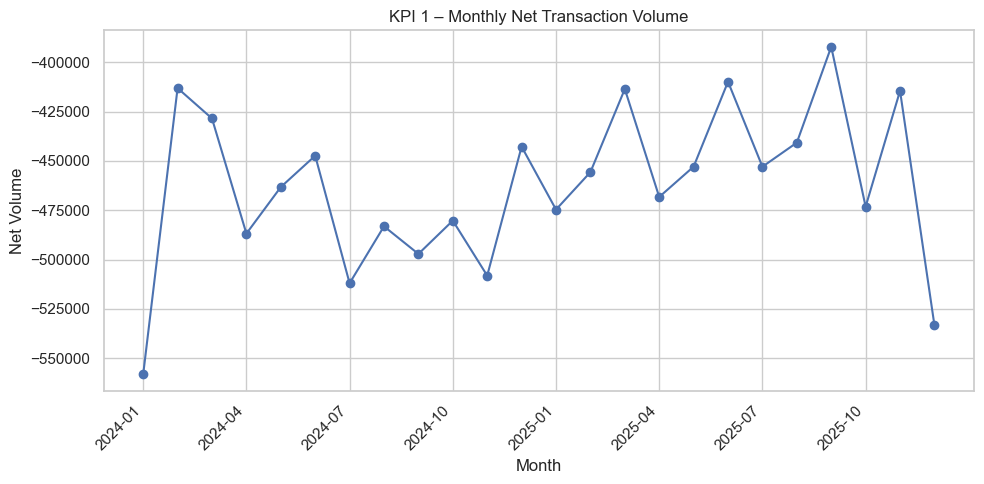

In [32]:
# KPI 1: Net transaction volume per month
kpi1_monthly_net = (
    clean_df.groupby("year_month")["amount_clipped"]
    .sum()
    .reset_index()
    .sort_values("year_month")
)

fig_kpi1, ax_kpi1 = plt.subplots(figsize=(10, 5))
ax_kpi1.plot(kpi1_monthly_net["year_month"],
             kpi1_monthly_net["amount_clipped"],
             marker="o")
ax_kpi1.set_xticks(kpi1_monthly_net["year_month"][::3])
ax_kpi1.set_xticklabels(kpi1_monthly_net["year_month"][::3],
                        rotation=45, ha="right")
ax_kpi1.set_title("KPI 1 – Monthly Net Transaction Volume")
ax_kpi1.set_xlabel("Month")
ax_kpi1.set_ylabel("Net Volume")
plt.tight_layout()


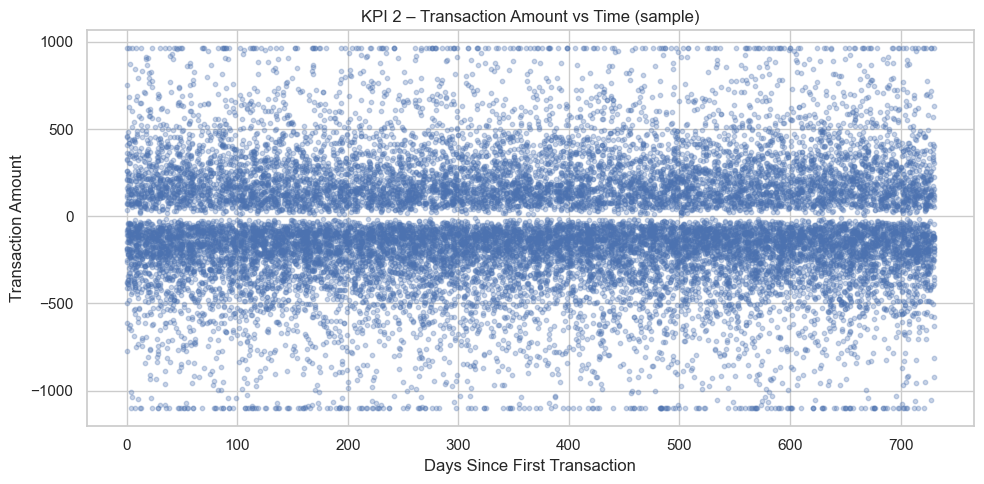

In [47]:
# KPI 2 – Transaction Amount vs Time (Scatterplot)
# =========================================
clean_df_sorted = clean_df.sort_values("transaction_date").copy()
clean_df_sorted["day_index"] = (
    clean_df_sorted["transaction_date"] -
    clean_df_sorted["transaction_date"].min()
).dt.days

sample_scatter = clean_df_sorted.sample(20_000, random_state=42)

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 5))
ax_scatter.scatter(sample_scatter["day_index"],
                   sample_scatter["amount_clipped"],
                   alpha=0.3, s=10)
ax_scatter.set_title("KPI 2 – Transaction Amount vs Time (sample)")
ax_scatter.set_xlabel("Days Since First Transaction")
ax_scatter.set_ylabel("Transaction Amount")
plt.tight_layout()
plt.show()


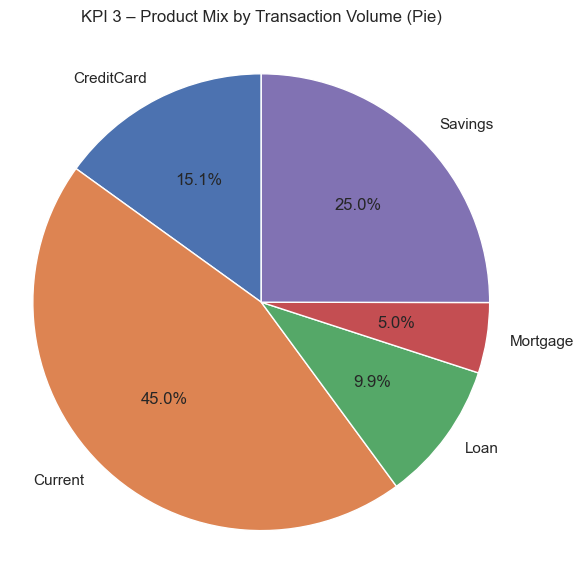

In [42]:
# KPI 3: Product share of total transaction volume
kpi3_product_volume = (
    clean_df.groupby("product_type")["abs_amount"]
    .sum()
    .reset_index()
    .rename(columns={"abs_amount": "total_volume"})
)

fig_kpi3, ax_kpi3 = plt.subplots(figsize=(6, 6))
ax_kpi3.pie(kpi3_product_volume["total_volume"],
            labels=kpi3_product_volume["product_type"],
            autopct="%1.1f%%",
            startangle=90)
ax_kpi3.set_title("KPI 3 – Product Mix by Transaction Volume (Pie)")
ax_kpi3.axis("equal")
plt.tight_layout()


## Export PDF report with charts, Insights & Recommendations

In [49]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# =========================================
# STEP 6 – Export PDF Report with Charts + Insights
# =========================================

output_pdf_path = "bank_kpi_report_with_insights.pdf"

# Helper function to create a text-only page
def create_text_page(title, insights_list):
    """
    Create a matplotlib figure with text-only content for insights
    """
    fig, ax = plt.subplots(figsize=(8.5, 11))  # Letter size
    ax.axis('off')
    
    # Title
    ax.text(0.5, 0.95, title, 
            ha='center', va='top', 
            fontsize=16, fontweight='bold',
            transform=ax.transAxes)
    
    # Insights text
    y_position = 0.88
    for item in insights_list:
        # Wrap long text manually or use textwrap
        ax.text(0.1, y_position, item,
                ha='left', va='top',
                fontsize=10,
                wrap=True,
                transform=ax.transAxes)
        y_position -= 0.12  # Space between paragraphs
    
    plt.tight_layout()
    return fig

# =========================================
# Build PDF with Charts + Insight Pages
# =========================================

with PdfPages(output_pdf_path) as pdf:
    
    # ---------- Page 1: Line Chart ----------
    pdf.savefig(fig_line)
    
    # ---------- Page 2: Insights for Line Chart ----------
    insights_line = [
        "✓ INSIGHTS - Monthly Net Transaction Volume:",
        "",
        "• Positive trend = healthy liquidity (more deposits than withdrawals)",
        "• Declining months = potential churn or competitive pressure",
        "• Sharp spikes/drops = investigate campaigns, fees, or macro events",
        "",
        "✓ RECOMMENDATIONS:",
        "• Deploy excess liquidity into higher-yield products (loans, investments)",
        "• Analyze negative-flow months to design retention campaigns",
        "• Track monthly as early warning for liquidity and satisfaction"
    ]
    fig_text_line = create_text_page("KPI 1 – Insights & Recommendations", insights_line)
    pdf.savefig(fig_text_line)
    plt.close(fig_text_line)
    
    # ---------- Page 3: Scatterplot ----------
    pdf.savefig(fig_scatter)
    
    # ---------- Page 4: Insights for Scatterplot ----------
    insights_scatter = [
        "✓ INSIGHTS - Transaction Amount vs Time:",
        "",
        "• Dense band near zero = most transactions are small everyday banking",
        "• Outliers at extremes = high-value customers or business accounts (VIP)",
        "• Stable pattern over time = consistent behavior, no structural breaks",
        "",
        "✓ RECOMMENDATIONS:",
        "• Prioritize relationship managers for high-value outliers (VIP service)",
        "• Segment customers by transaction size and tailor product offerings",
        "• Use as input for fraud detection (unusual large transactions)",
        "• Consider micro-loans for small spenders, wealth mgmt for high-value"
    ]
    fig_text_scatter = create_text_page("KPI 2 – Insights & Recommendations", insights_scatter)
    pdf.savefig(fig_text_scatter)
    plt.close(fig_text_scatter)
    
    # ---------- Page 5: Pie Chart ----------
    pdf.savefig(fig_pie)
    
    # ---------- Page 6: Insights for Pie Chart ----------
    insights_pie = [
        "✓ INSIGHTS - Product Mix by Transaction Volume:",
        "",
        "• Current (45%) + Savings (25%) = 70% of volume → deposit-heavy bank",
        "• CreditCard (15%), Loan (10%), Mortgage (5%) = underpenetrated",
        "• Low-margin transactional products dominate → cross-sell opportunity",
        "",
        "✓ RECOMMENDATIONS:",
        "• Target Current/Savings holders with pre-approved credit offers",
        "• Bundle products (mortgage + savings + credit card discounts/rewards)",
        "• Focus marketing on underrepresented high-margin products",
        "• Track product mix shift over time as strategic success metric",
        "• Drill down by region/channel to find best cross-sell opportunities"
    ]
    fig_text_pie = create_text_page("KPI 3 – Insights & Recommendations", insights_pie)
    pdf.savefig(fig_text_pie)
    plt.close(fig_text_pie)

print(f"✓ PDF report with insights saved to: {output_pdf_path}")


C:\Users\horry\AppData\Local\Temp\ipykernel_35904\3474231972.py:36: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\horry\AppData\Local\Temp\ipykernel_35904\3474231972.py:62: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  pdf.savefig(fig_text_line)
C:\Users\horry\AppData\Local\Temp\ipykernel_35904\3474231972.py:83: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  pdf.savefig(fig_text_scatter)
C:\Users\horry\AppData\Local\Temp\ipykernel_35904\3474231972.py:105: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  pdf.savefig(fig_text_pie)


✓ PDF report with insights saved to: bank_kpi_report_with_insights.pdf


## KPIs summary

In [56]:
import pandas as pd

# =========================================
# KPI SUMMARY – CORE METRICS
# Assumes clean_df with:
# amount_clipped, abs_amount, year_month, channel,
# product_type, customer_id, region
# =========================================

def build_kpi_summary(df: pd.DataFrame) -> pd.DataFrame:
    # Overall transaction metrics
    total_txn_count = len(df)
    total_volume = df["amount_clipped"].sum()
    total_inflow = df.loc[df["amount_clipped"] > 0, "amount_clipped"].sum()
    total_outflow = df.loc[df["amount_clipped"] < 0, "amount_clipped"].sum()
    avg_txn_amount = df["amount_clipped"].mean()
    
    # Customer / product / channel metrics
    unique_customers = df["customer_id"].nunique()
    unique_accounts = df["account_id"].nunique()
    unique_products = df["product_type"].nunique()
    unique_channels = df["channel"].nunique()
    
    # Time-based metrics
    first_date = df["transaction_date"].min()
    last_date = df["transaction_date"].max()
    active_days = (last_date - first_date).days + 1
    
    # Monthly metrics (using year_month)
    monthly_net = df.groupby("year_month")["amount_clipped"].sum()
    avg_monthly_net = monthly_net.mean()
    max_month_net = monthly_net.max()
    min_month_net = monthly_net.min()
    
    # Build summary as a tidy DataFrame
    data = {
        "KPI": [
            "Total transactions",
            "Total net volume",
            "Total inflow",
            "Total outflow",
            "Average transaction amount",
            "Unique customers",
            "Unique accounts",
            "Unique products",
            "Unique channels",
            "First transaction date",
            "Last transaction date",
            "Active days in dataset",
            "Average monthly net volume",
            "Best month net volume",
            "Worst month net volume",
        ],
        "Value": [
            total_txn_count,
            total_volume,
            total_inflow,
            total_outflow,
            avg_txn_amount,
            unique_customers,
            unique_accounts,
            unique_products,
            unique_channels,
            first_date,
            last_date,
            active_days,
            avg_monthly_net,
            max_month_net,
            min_month_net,
        ],
    }
    
    kpi_summary_df = pd.DataFrame(data)
    return kpi_summary_df


# Build and display KPI summary
kpi_summary = build_kpi_summary(clean_df)
kpi_summary


,KPI,Value
0,Total transactions,199202
1,Total net volume,-11101539.654906
2,Total inflow,21137754.271838
3,Total outflow,-32239293.926743
4,Average transaction amount,-55.730061
5,Unique customers,20000
6,Unique accounts,49093
7,Unique products,5
8,Unique channels,6
9,First transaction date,2024-01-01 00:00:00
